In [339]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Path to dataset files: /Users/anantmishra/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


In [340]:
import pandas as pd

In [341]:
data = pd.read_csv(r"/Users/anantmishra/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1/IMDB Dataset.csv")

In [342]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


/var/folders/9j/kpj62g1s4xv0hvl_mc8739hh0000gn/T/ipykernel_12356/1983538975.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=data, palette='viridis')


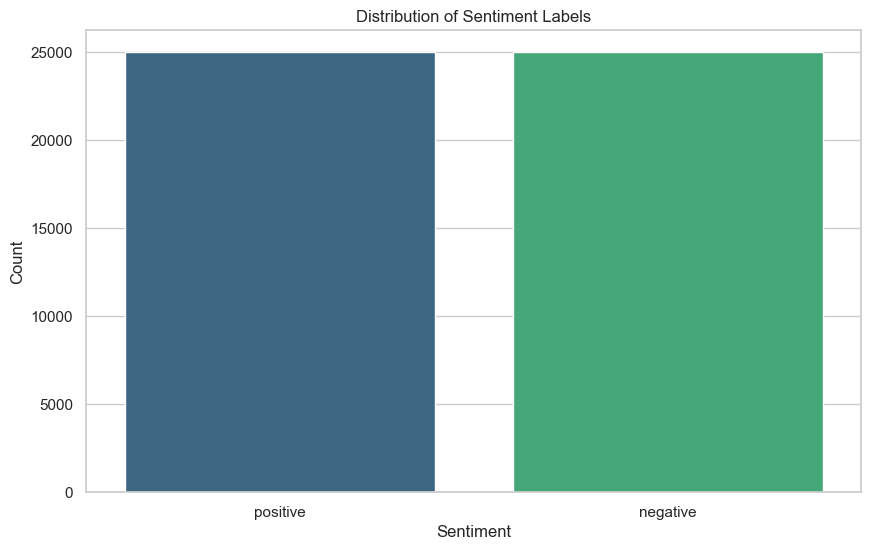

In [343]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment', data=data, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

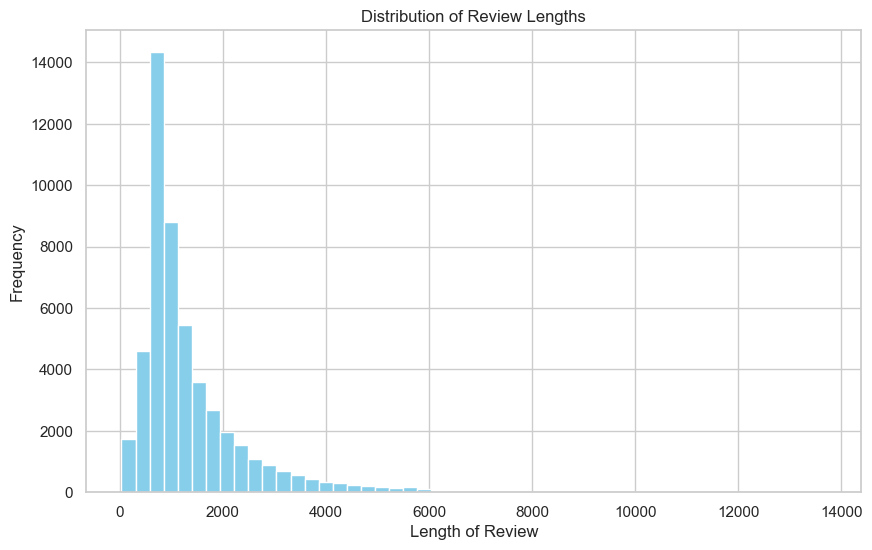

In [344]:
data['review'].str.len().plot(kind='hist', bins=50, figsize=(10, 6), color='skyblue')
plt.title('Distribution of Review Lengths')
plt.xlabel('Length of Review')
plt.ylabel('Frequency')
plt.show()  

In [345]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop=set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/anantmishra/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [346]:
corpus=[]
new= data['review'].str.split()
new=new.values.tolist()
corpus=[word for i in new for word in i]

from collections import defaultdict
dic=defaultdict(int)
for word in corpus:
    if word in stop:
        dic[word]+=1

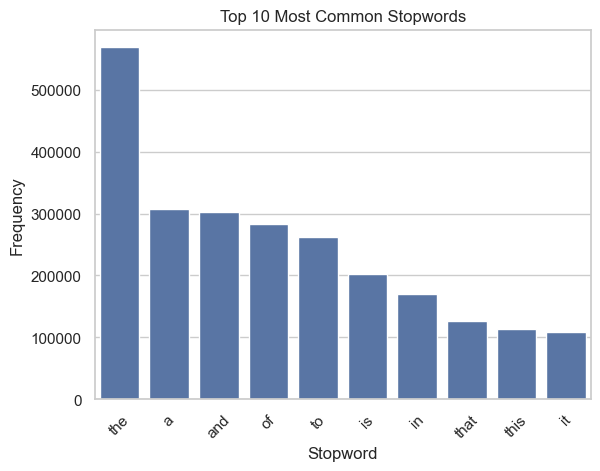

In [347]:
# Get top 10 stopwords by frequency from dic
top_stopwords = sorted(dic.items(), key=lambda item: item[1], reverse=True)[:10]
stopword_names = [item[0] for item in top_stopwords]
stopword_counts = [item[1] for item in top_stopwords]

sns.barplot(x=stopword_names, y=stopword_counts)
plt.xticks(rotation=45)
plt.title('Top 10 Most Common Stopwords')
plt.xlabel('Stopword')
plt.ylabel('Frequency')
plt.show()

<Axes: >

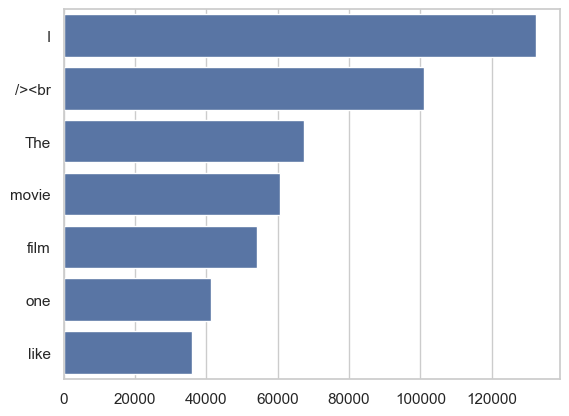

In [348]:
from collections import Counter

counter=Counter(corpus)
most=counter.most_common()

x, y= [], []
for word,count in most[:40]:
    if (word not in stop):
        x.append(word)
        y.append(count)

sns.barplot(x=y,y=x)

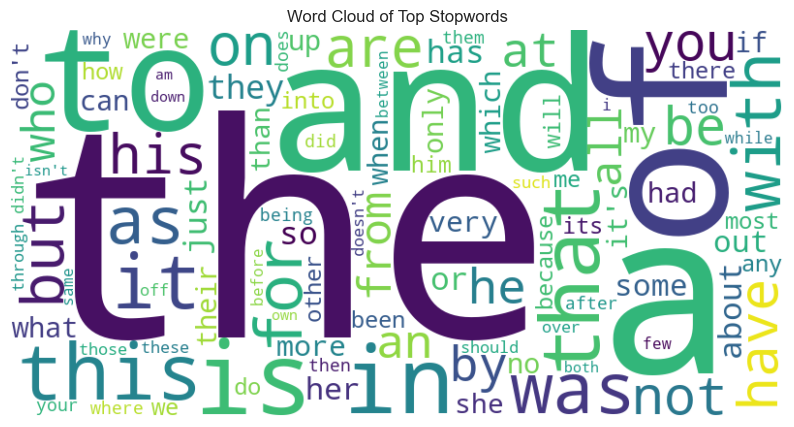

In [349]:
from wordcloud import WordCloud

# Create a dictionary for stopwords and their counts
top_stopwords = sorted(dic.items(), key=lambda item: item[1], reverse=True)[:100]
stopword_freq = dict(top_stopwords)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(stopword_freq)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Top Stopwords')
plt.show()

In [350]:
# Remove stopwords from the reviews
data['review'] = data['review'].apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in stop]))

In [351]:
import re
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Remove special characters and digits
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Tokenize
    words = text.split()
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    # Remove extra spaces and join
    return ' '.join(words)

# Apply cleaning to the 'review' column
data['review'] = data['review'].apply(lambda x: clean_text(x))


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/anantmishra/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/anantmishra/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [352]:
data['review_len'] = data['review'].apply(lambda x: len(x.split()))

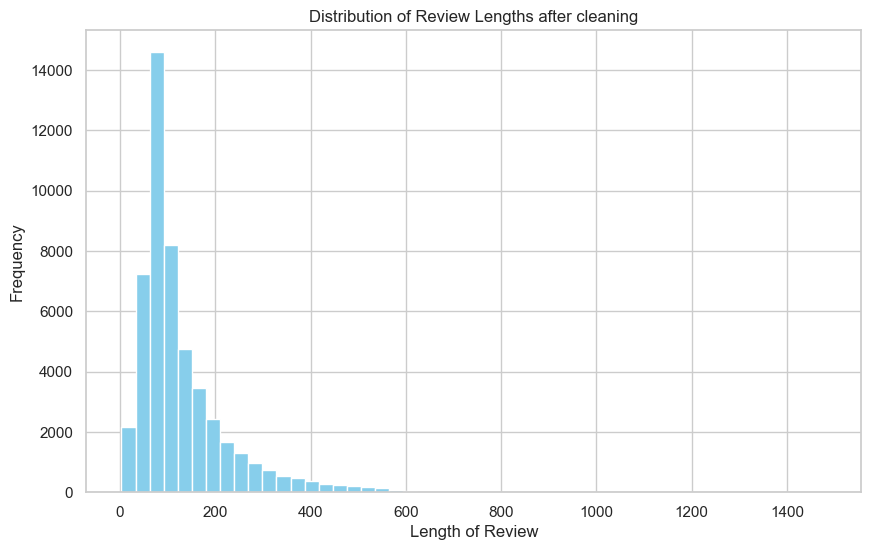

In [353]:
data['review_len'].plot(kind='hist', bins=50, figsize=(10, 6), color='skyblue')
plt.title('Distribution of Review Lengths after cleaning')
plt.xlabel('Length of Review')
plt.ylabel('Frequency')
plt.show()  

In [354]:
from sklearn.preprocessing import LabelEncoder
sentiment_encoder = LabelEncoder()
data['sentiment'] = sentiment_encoder.fit_transform(data['sentiment'])

In [355]:
max_len_review = data['review_len'].max()
print(max_len_review)

1482


In [356]:
count_records_800 = 0
for x in data['review_len']:
    if x > 800:
        count_records_800 += 1
print(f"Number of reviews longer than 800 words: {count_records_800}")

Number of reviews longer than 800 words: 12


In [357]:
data = data[data['review_len'] <= 800].reset_index(drop=True)

In [358]:
vocab = []
word2idx = {"<UNK>": 2, "<PAD>": 1}
index2word = {1: "<PAD>", 2: "<UNK>"}
for x in data['review']:
    for word in x.split():
        if word not in vocab:
            vocab.append(word)
            word2idx[word] = len(vocab) + 1
            index2word[len(vocab) + 1] = word

In [359]:
data['review_tokens'] = data['review'].apply(lambda x: [word2idx[word] for word in x.split() if word in word2idx])

In [360]:
max_len_review = data['review_len'].max()
print(f"Maximum length of review after cleaning: {max_len_review}")
data['review_padded_tokens'] = data['review_tokens'].apply(lambda x: x[:max_len_review] + [word2idx["<PAD>"]] * (max_len_review - len(x)))


Maximum length of review after cleaning: 789


In [361]:
import torch
torch.manual_seed(42)  # For reproducibility
torch.mps.manual_seed(42)  # For reproducibility on MPS backend
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [439]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {"features":torch.tensor(self.x.iloc[idx], device = device),
               "labels":torch.tensor(self.y.iloc[idx], dtype=torch.float, device = device)}

In [440]:
import torch.nn.functional as F
import torch.nn as nn

class SentimentClassifier(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_dim):
        super(SentimentClassifier, self).__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)  # [batch_size, seq_len, embedding_dim]
        x = x.mean(dim=1)       # [batch_size, embedding_dim]
        x = F.relu(self.fc1(x)) # [batch_size, hidden_dim]
        x = self.fc2(x)         # [batch_size, 1]
        return x.squeeze(1)     # [batch_size]

In [441]:
X = data['review_padded_tokens']
y = data['sentiment']

In [442]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [443]:
train_dataset = SentimentDataset(X_train, y_train)
test_dataset = SentimentDataset(X_test, y_test)

In [444]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True, drop_last=True)

In [445]:
model = SentimentClassifier(num_embeddings = 800, embedding_dim=100, hidden_dim=128).to(device)

In [446]:
model.parameters

<bound method Module.parameters of SentimentClassifier(
  (embedding): Embedding(800, 100)
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)>

In [447]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [448]:
n_epochs = 100
train_losses = []
test_losses = []

for x in range(n_epochs):
    model.train()
    train_loss = 0
    for _ ,batch in enumerate(train_dataloader):
        X_batch = batch['features'].to(device)
        y_batch = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_dataloader)
    train_losses.append(train_loss)
    if (x+1) % 5 == 0:
        print(f"Epoch {x+1}/{n_epochs}, Train Loss: {train_loss:.4f}")
    
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for _, batch in enumerate(test_dataloader):
            X_batch = batch['features'].to(device)
            y_batch = batch['labels'].to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item()
    test_loss /= len(test_dataloader)
    test_losses.append(test_loss)
    if (x+1) % 5 == 0:
        print(f"Epoch {x+1}/{n_epochs}, Test Loss: {test_loss:.4f}")


Epoch 5/100, Train Loss: 0.4305
Epoch 5/100, Test Loss: 0.4383
Epoch 10/100, Train Loss: 0.4036
Epoch 10/100, Test Loss: 0.4010
Epoch 15/100, Train Loss: 0.3942
Epoch 15/100, Test Loss: 0.3936
Epoch 20/100, Train Loss: 0.3922
Epoch 20/100, Test Loss: 0.3900
Epoch 25/100, Train Loss: 0.3878
Epoch 25/100, Test Loss: 0.3904
Epoch 30/100, Train Loss: 0.3853
Epoch 30/100, Test Loss: 0.4247
Epoch 35/100, Train Loss: 0.3845
Epoch 35/100, Test Loss: 0.3950
Epoch 40/100, Train Loss: 0.3818
Epoch 40/100, Test Loss: 0.3972
Epoch 45/100, Train Loss: 0.3809
Epoch 45/100, Test Loss: 0.3873
Epoch 50/100, Train Loss: 0.3796
Epoch 50/100, Test Loss: 0.3894
Epoch 55/100, Train Loss: 0.3778
Epoch 55/100, Test Loss: 0.4045
Epoch 60/100, Train Loss: 0.3765
Epoch 60/100, Test Loss: 0.3871
Epoch 65/100, Train Loss: 0.3770
Epoch 65/100, Test Loss: 0.3866
Epoch 70/100, Train Loss: 0.3762
Epoch 70/100, Test Loss: 0.3856
Epoch 75/100, Train Loss: 0.3751
Epoch 75/100, Test Loss: 0.3898
Epoch 80/100, Train Loss: 0

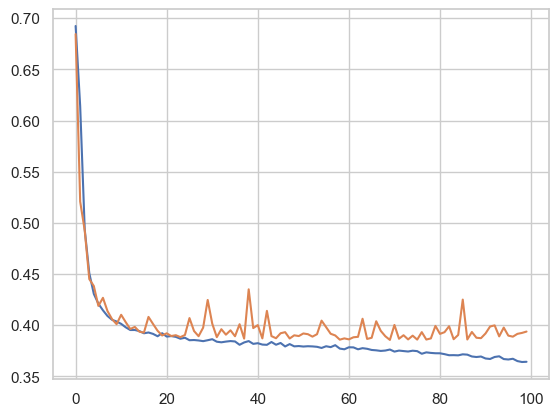

In [449]:
plt.plot(range(n_epochs),torch.tensor(train_losses))
plt.plot(range(n_epochs),torch.tensor(test_losses))

In [450]:
def predict_sentiment(model, text, word2idx, max_len_review):
    tokens = [word2idx.get(word, word2idx["<UNK>"]) for word in text.split()]
    tokens = tokens[:max_len_review] + [word2idx["<PAD>"]] * (max_len_review - len(tokens))
    tensor = torch.tensor(tokens, device=device).unsqueeze(0)  # Add batch dimension
    model.eval()
    with torch.no_grad():
        output = model(tensor)
        prediction = torch.sigmoid(output).item()
        sentiment = "Positive" if prediction >= 0.5 else "Negative"
    return sentiment, prediction


In [454]:
print(predict_sentiment(model, "This movie was fantastic! I loved it.", word2idx, max_len_review))
print(predict_sentiment(model, "The plot was okay, but the acting was great.", word2idx, max_len_review))
print(predict_sentiment(model, "I didn't like the movie at all. It was boring and predictable.", word2idx, max_len_review))
print(predict_sentiment(model, "The cinematography was stunning, but the story was weak.", word2idx, max_len_review))
print(predict_sentiment(model, "I was pleasantly surprised by this film. It exceeded my expectations.", word2idx, max_len_review))
print(predict_sentiment(model, "The acting was mediocre, but the story was compelling.", word2idx, max_len_review))
print(predict_sentiment(model, "This movie was a complete waste of time. I regret watching it.", word2idx, max_len_review))
print(predict_sentiment(model, "The soundtrack was amazing, but the plot was confusing.", word2idx, max_len_review))


('Positive', 0.7866058349609375)
('Negative', 0.3580160439014435)
('Negative', 0.18845339119434357)
('Positive', 0.5520992875099182)
('Positive', 0.5039171576499939)
('Negative', 0.4723888635635376)
('Negative', 0.05093321204185486)
('Positive', 0.5562619566917419)


In [457]:
torch.save(model.state_dict(), "sentiment_classifier.pth")
print("Model saved to sentiment_classifier.pth")

Model saved to sentiment_classifier.pth


In [ ]:
# import torch
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# torch.load("sentiment_classifier.pth", map_location=device)

OrderedDict([('embedding.weight',
              tensor([[-0.8898,  0.5997, -0.1428,  ..., -0.5157,  0.0948, -1.0791],
                      [ 0.7079,  0.2866, -0.5392,  ...,  0.6079,  0.0502,  0.1417],
                      [-1.3993,  1.3201,  1.4398,  ..., -0.6502,  0.9054, -2.0994],
                      ...,
                      [ 1.2262,  1.2987,  2.1055,  ..., -1.0169, -1.6200, -0.7644],
                      [-0.9943,  0.6381,  1.2080,  ...,  2.8534, -0.1239,  0.9632],
                      [-3.6097, -2.6466, -2.8298,  ...,  1.7795,  0.2696,  1.9121]],
                     device='mps:0')),
             ('fc1.weight',
              tensor([[-0.1995, -0.1734, -0.1910,  ...,  0.0441,  0.6247,  0.3404],
                      [ 0.0117,  0.0877, -0.0649,  ..., -0.0613, -0.0740, -0.1020],
                      [-0.0283, -0.2591, -0.2330,  ...,  0.0517,  0.6442,  0.3481],
                      ...,
                      [ 0.0349, -0.2913, -0.0215,  ...,  0.0233,  0.5220,  0.3048],
    